In [1]:
from v2_data_preparation import process_modis, process_landsat, process_insitu
from v2_sensor_fusion import fuse_sensors
from v2_feature_engineering import build_features_dataset, join_datasets, compute_spectral_indices, run_pca

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# -----------------------------
# 1. Study site selection and config
# -----------------------------

study_site = 'SDH2'
start_date = '2000'
end_date = '2026'

if study_site == 'SDH1':
    target = 'SDH1PS01_gw-depth_m'
    insitu_filepath = '../data/processed/in-situ/SDH1_daily-insitu-data.csv'
    modis_filepath = '../data/processed/satellites/SDH1_MT_500m_2000-03_2026-06.csv'
    landsat_filepath = '../data/processed/satellites/SDH1_L_30m_1984-07_2026-06.csv'

elif study_site == 'SDH2':
    target = 'SDH2PP01_gw-depth_m'
    insitu_filepath = '../data/processed/in-situ/SDH2_daily-insitu-data.csv'
    modis_filepath = '../data/processed/satellites/SDH2_MT_500m_2000-03_2026-06.csv'
    landsat_filepath = '../data/processed/satellites/SDH2_L_30m_1984-07_2026-06.csv'

else:
    print(f'{study_site} not supported as study site')

band_mapping = {
    'blue':  ('blue_mean',  'blue'),
    'green': ('green_mean', 'green'),
    'red':   ('red_mean',   'red'),
    'nir':   ('nir_mean',   'nir'),
    'swir1': ('swir1_mean', 'swir1'),
    'swir2': ('swir2_mean', 'swir2')
}

modis_cols = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
landsat_cols = ['blue_mean', 'green_mean', 'red_mean', 'nir_mean', 'swir1_mean', 'swir2_mean']

features = [
    'ndvi',
    'gndvi',
    'ndwi',
    'mndwi',
    'ndmi',
    'ndmi2',
    'str1',
    'str2',
]

# -----------------------------
# 2. Input data preprocessing
# -----------------------------

modis_df = process_modis(
    filepath=modis_filepath,
    start_date=start_date,
    end_date=end_date,
    cols_to_keep=modis_cols,
    outlier_threshold=3.0,
    smooth_window=31
)

landsat_df = process_landsat(
    filepath=landsat_filepath,
    start_date=start_date,
    end_date=end_date,
    cols_to_keep=landsat_cols,
    outlier_threshold=3.0,
    stats_min_points=10
)

insitu_df = process_insitu(
    filepath=insitu_filepath,
    start_date='2024-05-24',
    end_date='2026-05-14',
    cols_to_keep=target,
    outlier_threshold=3.0
    )

# -----------------------------
# 3. Daily satellite series
# -----------------------------

sensor_fusion_results = fuse_sensors(
    modis_df=modis_df,
    landsat_df=landsat_df,
    band_mapping=band_mapping,
    test_size=0.3,
    sigma_threshold=3.0,
    verbose_summary=False,
    verbose_plots=False
)

# -----------------------------
# 4. Predictors and target processing
# -----------------------------

indices = compute_spectral_indices(sensor_fusion_results['predicted'])
pca_df, pca_model, loadings_df, pc_names = run_pca(indices, features, 2, 42, False)

/opt/miniconda3/envs/ML/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Processing blue (650 coincident points)
Train - R2: 0.721 | MAE: 0.048 | RMSE: 0.063
Test  - R2: 0.703  | MAE: 0.044  | RMSE: 0.057

Processing green (707 coincident points)
Train - R2: 0.742 | MAE: 0.042 | RMSE: 0.056
Test  - R2: 0.676  | MAE: 0.048  | RMSE: 0.063

Processing red (649 coincident points)
Train - R2: 0.726 | MAE: 0.046 | RMSE: 0.062
Test  - R2: 0.705  | MAE: 0.046  | RMSE: 0.062

Processing nir (730 coincident points)
Train - R2: 0.63 | MAE: 0.045 | RMSE: 0.061
Test  - R2: 0.604  | MAE: 0.047  | RMSE: 0.062

Processing swir1 (722 coincident points)
Train - R2: 0.817 | MAE: 0.036 | RMSE: 0.049
Test  - R2: 0.826  | MAE: 0.034  | RMSE: 0.045

Processing swir2 (731 coincident points)
Train - R2: 0.859 | MAE: 0.031 | RMSE: 0.041
Test  - R2: 0.835  | MAE: 0.032  | RMSE: 0.044


In [2]:
pca_diff = pca_df.diff().dropna()
insitu_diff = insitu_df.diff().dropna()

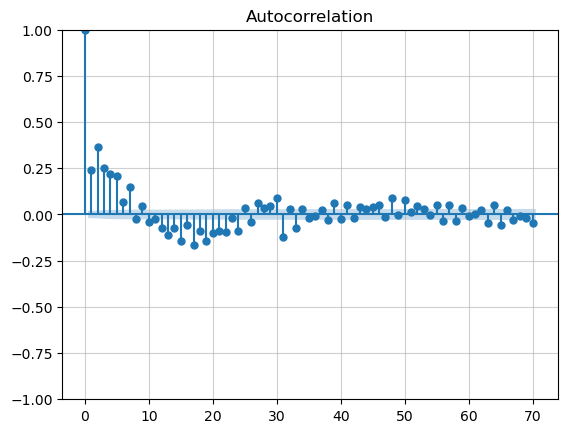

In [3]:
plot_acf(pca_diff['PC_1'], lags=70)
plt.grid(True, alpha=0.6)
plt.show()

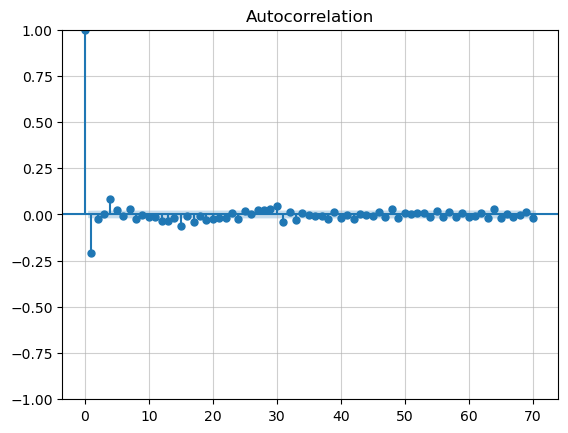

In [4]:
plot_acf(pca_diff['PC_2'], lags=70)
plt.grid(True, alpha=0.6)
plt.show()

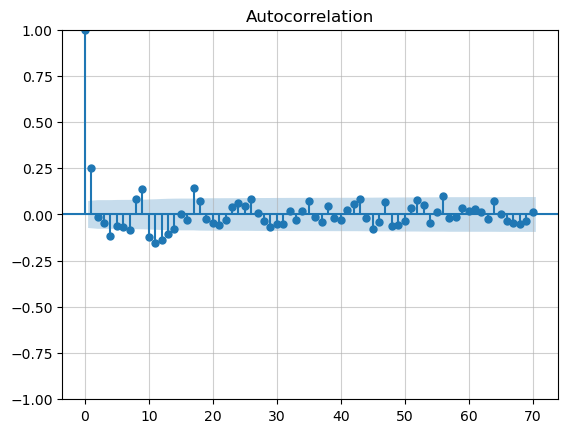

In [5]:
plot_acf(insitu_diff, lags=70)
plt.grid(True, alpha=0.6)
plt.show()